In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print("Uploaded file:", filename)

Saving biomedical-waste-report.csv to biomedical-waste-report.csv
Uploaded file: biomedical-waste-report.csv


In [3]:
df = pd.read_csv(filename)
print("Dataset loaded successfully!")
print()
print("First 5 rows of the dataset:")
display(df.head())

Dataset loaded successfully!

First 5 rows of the dataset:


,Period,Red KG,Blue KG,Yellow KG,White KG,Total KG
0,Jan-17,2783,1186,1783,0,5752
1,Feb-17,2647,1023,1887,0,5557
2,Mar-17,2816,961,1940,0,5717
3,Apr-17,2896,858,1813,0,5567
4,May-17,3007,882,1787,0,5676


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("\nColumn names:")
for column in df.columns:
    print("-", column)

Number of rows: 117
Number of columns: 6

Column names:
- Period
- Red KG
- Blue KG
- Yellow KG
- White KG
- Total KG


In [5]:
print("Missing values in each column:\n")
print(df.isnull().sum())

Missing values in each column:

Period       0
Red KG       0
Blue KG      0
Yellow KG    0
White KG     0
Total KG     0
dtype: int64


In [6]:
waste_columns = [
    "Red KG",
    "Blue KG",
    "Yellow KG",
    "White KG",
    "Total KG"
]
for column in waste_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")
df = df.dropna()
print("Data cleaning completed successfully!")
print("Rows after cleaning:", len(df))

Data cleaning completed successfully!
Rows after cleaning: 117


In [7]:
print("STATISTICAL SUMMARY")
print("===================")
display(df[waste_columns].describe())

STATISTICAL SUMMARY


,Red KG,Blue KG,Yellow KG,White KG,Total KG
count,117.000000,117.000000,117.000000,117.000000,117.000000
mean,2425.324786,851.846154,3237.965812,97.059829,6678.521368
std,738.210696,351.019319,1506.369470,52.706456,2237.234121
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2295.000000,678.000000,2281.000000,74.000000,5850.000000
50%,2480.000000,802.000000,3262.000000,92.000000,6562.000000
75%,2765.000000,1069.000000,4176.000000,134.000000,8012.000000
max,3664.000000,1577.000000,10347.000000,274.000000,13422.000000


In [8]:
category_totals = {
    "Red Waste": df["Red KG"].sum(),
    "Blue Waste": df["Blue KG"].sum(),
    "Yellow Waste": df["Yellow KG"].sum(),
    "White Waste": df["White KG"].sum()
}
print("TOTAL WASTE BY CATEGORY")
print("========================")
for category, value in category_totals.items():
    print(category, ":", round(value, 2), "KG")

TOTAL WASTE BY CATEGORY
Red Waste : 283763 KG
Blue Waste : 99666 KG
Yellow Waste : 378842 KG
White Waste : 11356 KG


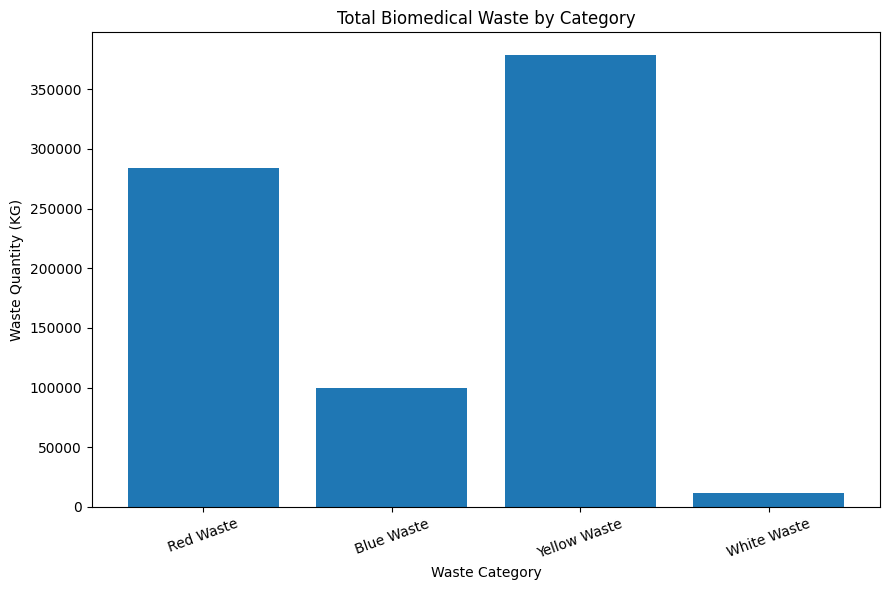

In [9]:
categories = list(category_totals.keys())
values = list(category_totals.values())
plt.figure(figsize=(9, 6))
plt.bar(categories, values)
plt.title("Total Biomedical Waste by Category")
plt.xlabel("Waste Category")
plt.ylabel("Waste Quantity (KG)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

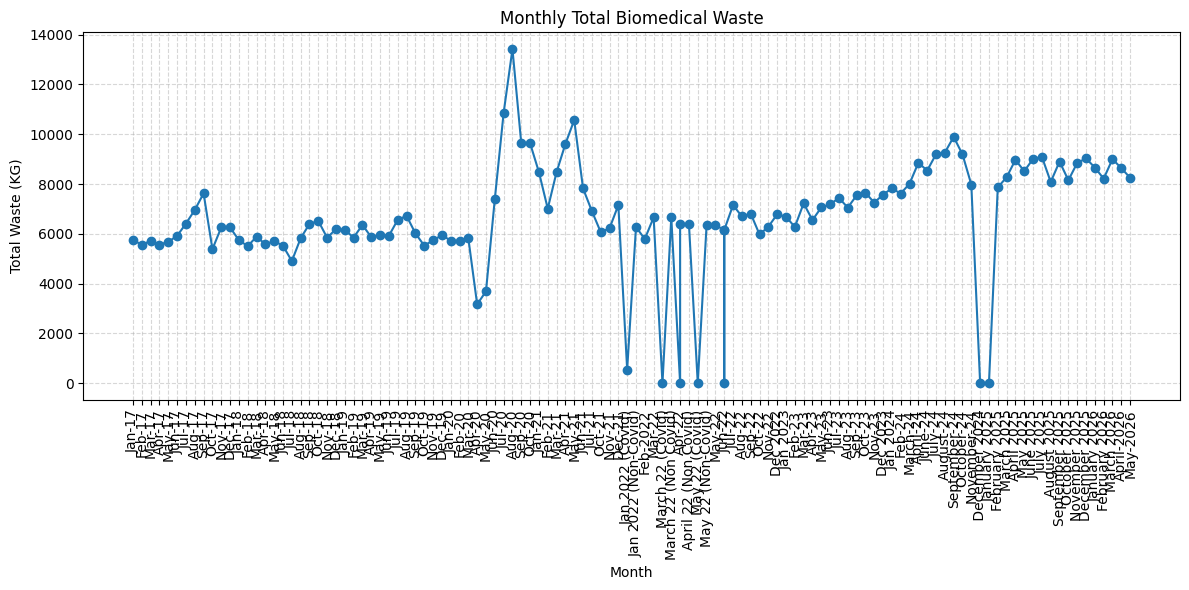

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(
    df["Period"],
    df["Total KG"],
    marker="o"
)
plt.title("Monthly Total Biomedical Waste")
plt.xlabel("Month")
plt.ylabel("Total Waste (KG)")
plt.xticks(rotation=90)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [11]:
X = df[
    [
        "Red KG",
        "Blue KG",
        "Yellow KG",
        "White KG"
    ]
]
y = df["Total KG"]
print("Input Features (X):")
print(X.columns.tolist())
print("\nTarget Variable (y):")
print("Total KG")

Input Features (X):
['Red KG', 'Blue KG', 'Yellow KG', 'White KG']

Target Variable (y):
Total KG


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Data splitting completed!")
print()
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Data splitting completed!

Training samples: 93
Testing samples: 24


In [13]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [14]:
y_pred = model.predict(X_test)
print("Predictions generated successfully!")
print("\nFirst 10 predictions:")
for i in range(min(10, len(y_pred))):
    print(
        "Actual:",
        round(y_test.iloc[i], 2),
        "KG   |   Predicted:",
        round(y_pred[i], 2),
        "KG"
    )

Predictions generated successfully!

First 10 predictions:
Actual: 9637 KG   |   Predicted: 9517.69 KG
Actual: 5676 KG   |   Predicted: 5656.51 KG
Actual: 6069 KG   |   Predicted: 6049.06 KG
Actual: 10852 KG   |   Predicted: 4546.84 KG
Actual: 6256 KG   |   Predicted: 6246.74 KG
Actual: 7541 KG   |   Predicted: 7533.78 KG
Actual: 6699 KG   |   Predicted: 6685.37 KG
Actual: 9192 KG   |   Predicted: 9202.74 KG
Actual: 5728 KG   |   Predicted: 5742.05 KG
Actual: 6254 KG   |   Predicted: 6234.83 KG


In [15]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MODEL PERFORMANCE")
print("=================")
print("MAE  :", round(mae, 2))
print("MSE  :", round(mse, 2))
print("RMSE :", round(rmse, 2))
print("R²   :", round(r2, 4))

MODEL PERFORMANCE
MAE  : 387.56
MSE  : 1932224.58
RMSE : 1390.04
R²   : 0.5955


In [16]:
results = pd.DataFrame({
    "Actual Total KG": y_test.values,
    "Predicted Total KG": np.round(y_pred, 2)
})
print("ACTUAL VS PREDICTED")
print("===================")
display(results)

ACTUAL VS PREDICTED


,Actual Total KG,Predicted Total KG
0,9637,9517.69
1,5676,5656.51
2,6069,6049.06
3,10852,4546.84
4,6256,6246.74
5,7541,7533.78
6,6699,6685.37
7,9192,9202.74
8,5728,5742.05
9,6254,6234.83


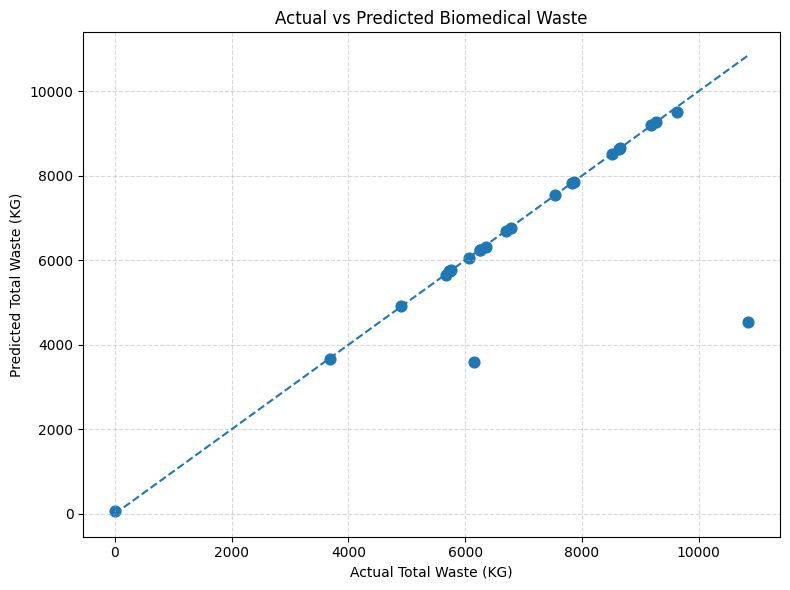

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(
    y_test,
    y_pred,
    s=60
)
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)
plt.title("Actual vs Predicted Biomedical Waste")
plt.xlabel("Actual Total Waste (KG)")
plt.ylabel("Predicted Total Waste (KG)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
new_data = pd.DataFrame({
    "Red KG": [3000],
    "Blue KG": [700],
    "Yellow KG": [2000],
    "White KG": [80]
})
prediction = model.predict(new_data)
print("NEW WASTE DATA")
print("==============")
print("Red Waste    :", 3000, "KG")
print("Blue Waste   :", 700, "KG")
print("Yellow Waste :", 2000, "KG")
print("White Waste  :", 80, "KG")
print()
print("Predicted Total Biomedical Waste:",
      round(prediction[0], 2), "KG")

NEW WASTE DATA
Red Waste    : 3000 KG
Blue Waste   : 700 KG
Yellow Waste : 2000 KG
White Waste  : 80 KG

Predicted Total Biomedical Waste: 5774.99 KG


In [19]:
results.to_csv(
    "medwaste_predictions.csv",
    index=False
)
print("Results saved successfully!")
print("File name: medwaste_predictions.csv")

Results saved successfully!
File name: medwaste_predictions.csv
